# 07 · Early-signal customer model

**Secondary business question:** can we identify, within 7 days of acquisition, which Instagram-acquired
customers are likely to become durable (repeat within 90 days)?

If yes, the brand can act early: suppress discount retargeting for customers who will return anyway, invest
in win-back for those at risk, and steer campaign design toward the signals that matter.

Only information available by day 7 is used (see `src/features.py`). The split is **time-based** — train on
customers acquired before mid-July, test on customers acquired after — so the evaluation mimics deploying the
model on future cohorts.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, precision_score, recall_score, brier_score_loss
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from features import build_customer_features, model_matrix, NUMERIC, CATEGORICAL, TARGET
import viz; viz.setup()
pd.set_option("display.width", 200, "display.max_columns", 60)

c = pd.read_csv("../data/processed/campaigns.csv", parse_dates=["campaign_date"])
cu = pd.read_csv("../data/processed/customers.csv", parse_dates=["acquisition_date", "first_purchase_date"])
o = pd.read_csv("../data/processed/orders.csv", parse_dates=["order_date"])
s = pd.read_csv("../data/processed/sessions.csv", parse_dates=["timestamp"])

df = build_customer_features(c, cu, s, o)
df.to_csv("../data/processed/customer_features.csv", index=False)
X, y = model_matrix(df)
print(X.shape, f"target rate = {y.mean():.3f}")
df[NUMERIC].describe().T.round(3)

(40947, 56) target rate = 0.405


,count,mean,std,min,25%,50%,75%,max
virality_score,40947.0,1.044,1.520,-3.894,-0.107,0.842,2.090,4.667
is_viral,40947.0,0.223,0.416,0.000,0.000,0.000,0.000,1.000
log_reach,40947.0,13.806,1.125,7.787,13.089,13.761,14.739,16.137
share_rate,40947.0,0.007,0.006,0.001,0.003,0.005,0.010,0.043
save_rate,40947.0,0.012,0.006,0.002,0.008,0.013,0.016,0.028
save_to_share_ratio,40947.0,2.843,2.199,0.075,1.336,2.562,4.054,12.291
campaign_discount_pct,40947.0,8.762,8.213,0.000,0.000,10.000,15.000,30.000
first_order_discount_pct,40947.0,7.453,8.182,0.000,0.000,0.000,15.000,30.000
used_discount,40947.0,0.495,0.500,0.000,0.000,0.000,1.000,1.000
first_order_value,40947.0,88.396,63.054,11.330,41.510,77.270,100.870,505.620


## 1. Time-based split

In [2]:
SPLIT = pd.Timestamp("2025-07-15")
tr, te = df.acquisition_date < SPLIT, df.acquisition_date >= SPLIT
Xtr, ytr, Xte, yte = X[tr], y[tr], X[te], y[te]
print(f"train: {tr.sum():,} customers (acquired < {SPLIT.date()}), repeat rate {ytr.mean():.3f}")
print(f"test : {te.sum():,} customers (acquired ≥ {SPLIT.date()}), repeat rate {yte.mean():.3f}")

train: 34,568 customers (acquired < 2025-07-15), repeat rate 0.403
test : 6,379 customers (acquired ≥ 2025-07-15), repeat rate 0.415


## 2. Models: logistic regression baseline vs tree ensembles

In [3]:
models = {
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=0.5)),
    "Random forest": RandomForestClassifier(n_estimators=400, min_samples_leaf=25, max_features="sqrt", n_jobs=-1, random_state=0),
    "Gradient boosting": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=0),
}
proba, rows = {}, []
for name, m in models.items():
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xte)[:, 1]; proba[name] = p
    pred = (p >= 0.5).astype(int)
    rows.append({"model": name, "ROC-AUC": roc_auc_score(yte, p), "PR-AUC": average_precision_score(yte, p),
                 "precision@0.5": precision_score(yte, pred), "recall@0.5": recall_score(yte, pred), "Brier": brier_score_loss(yte, p)})
perf = pd.DataFrame(rows).set_index("model")
perf.round(3)

,ROC-AUC,PR-AUC,precision@0.5,recall@0.5,Brier
model,,,,,
Logistic regression,0.683,0.641,0.629,0.384,0.213
Random forest,0.676,0.635,0.664,0.327,0.216
Gradient boosting,0.679,0.635,0.646,0.357,0.214


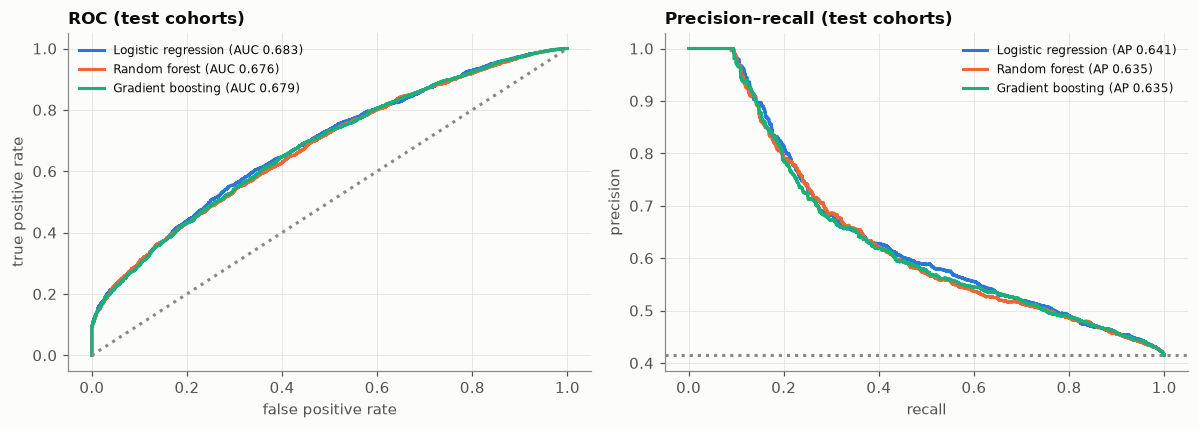

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for (name, p), col in zip(proba.items(), viz.SERIES):
    fpr, tpr, _ = roc_curve(yte, p); ax[0].plot(fpr, tpr, color=col, label=f"{name} (AUC {roc_auc_score(yte, p):.3f})")
    pr, rc, _ = precision_recall_curve(yte, p); ax[1].plot(rc, pr, color=col, label=f"{name} (AP {average_precision_score(yte, p):.3f})")
ax[0].plot([0, 1], [0, 1], color=viz.MUTED, linestyle=":"); ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate"); ax[0].set_title("ROC (test cohorts)"); ax[0].legend(fontsize=8)
ax[1].axhline(yte.mean(), color=viz.MUTED, linestyle=":"); ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision"); ax[1].set_title("Precision–recall (test cohorts)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig("../images/07_roc_pr.png"); plt.show()

The three models are close; the non-linear ensembles add only a little over the logistic baseline, which
says the signal is mostly additive and interpretable. We keep **gradient boosting** for scoring and the
**logistic model** for explanation.

## 3. Which early signals matter?

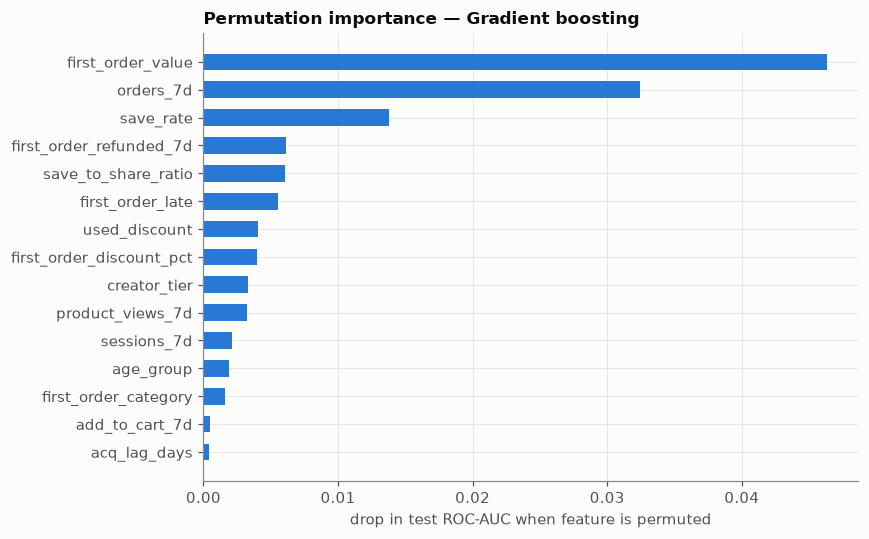

first_order_value           0.0463
orders_7d                   0.0325
save_rate                   0.0138
first_order_refunded_7d     0.0062
save_to_share_ratio         0.0060
first_order_late            0.0055
used_discount               0.0040
first_order_discount_pct    0.0040
creator_tier                0.0033
product_views_7d            0.0032
sessions_7d                 0.0021
age_group                   0.0019
first_order_category        0.0016
add_to_cart_7d              0.0005
acq_lag_days                0.0004
dtype: float64

In [5]:
best = "Gradient boosting"
pi = permutation_importance(models[best], Xte, yte, scoring="roc_auc", n_repeats=8, random_state=0, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X.columns)
# fold one-hot columns back to their source feature
src = imp.index.to_series().apply(lambda k: next((cat for cat in CATEGORICAL if k.startswith(cat + "_")), k))
imp_grouped = imp.groupby(src.values).sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
d = imp_grouped.head(15)[::-1]
ax.barh(d.index, d.values, color=viz.SERIES[0], height=0.6); ax.set_xlabel("drop in test ROC-AUC when feature is permuted"); ax.set_title(f"Permutation importance — {best}")
plt.tight_layout(); plt.savefig("../images/07_permutation_importance.png"); plt.show()
imp_grouped.round(4).head(15)

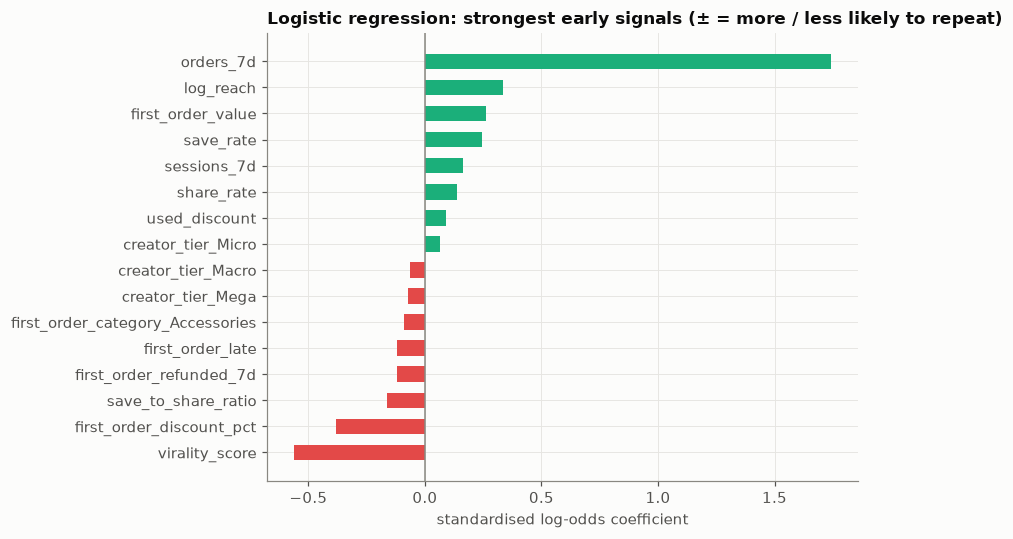

In [6]:
lr = models["Logistic regression"]
coef = pd.Series(lr.named_steps["logisticregression"].coef_[0], index=X.columns).sort_values()
show = pd.concat([coef.head(8), coef.tail(8)])
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(show.index, show.values, color=[viz.SERIES[2] if v > 0 else viz.SERIES[7] for v in show.values], height=0.6)
ax.axvline(0, color=viz.MUTED, linewidth=1); ax.set_xlabel("standardised log-odds coefficient"); ax.set_title("Logistic regression: strongest early signals (± = more / less likely to repeat)")
plt.tight_layout(); plt.savefig("../images/07_logit_coefficients.png"); plt.show()

## 4. Does campaign virality add any predictive value?

Ablation: retrain without the campaign-level virality features (`virality_score`, `is_viral`, `log_reach`,
`share_rate`, `save_rate`, `save_to_share_ratio`).

In [7]:
viral_feats = ["virality_score", "is_viral", "log_reach", "share_rate", "save_rate", "save_to_share_ratio"]
keep = [k for k in X.columns if k not in viral_feats]
gb2 = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=0).fit(Xtr[keep], ytr)
gb3 = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=0).fit(Xtr[viral_feats], ytr)
print(f"full model              ROC-AUC = {perf.loc[best, 'ROC-AUC']:.3f}")
print(f"without virality feats  ROC-AUC = {roc_auc_score(yte, gb2.predict_proba(Xte[keep])[:, 1]):.3f}")
print(f"virality feats only     ROC-AUC = {roc_auc_score(yte, gb3.predict_proba(Xte[viral_feats])[:, 1]):.3f}")

full model              ROC-AUC = 0.679
without virality feats  ROC-AUC = 0.673
virality feats only     ROC-AUC = 0.565


## 5. Calibration and a decision-oriented view

If the brand targets the top 20% of new customers by predicted durability, what share of eventual repeaters
does it capture, and how much 90-day margin do those customers represent?

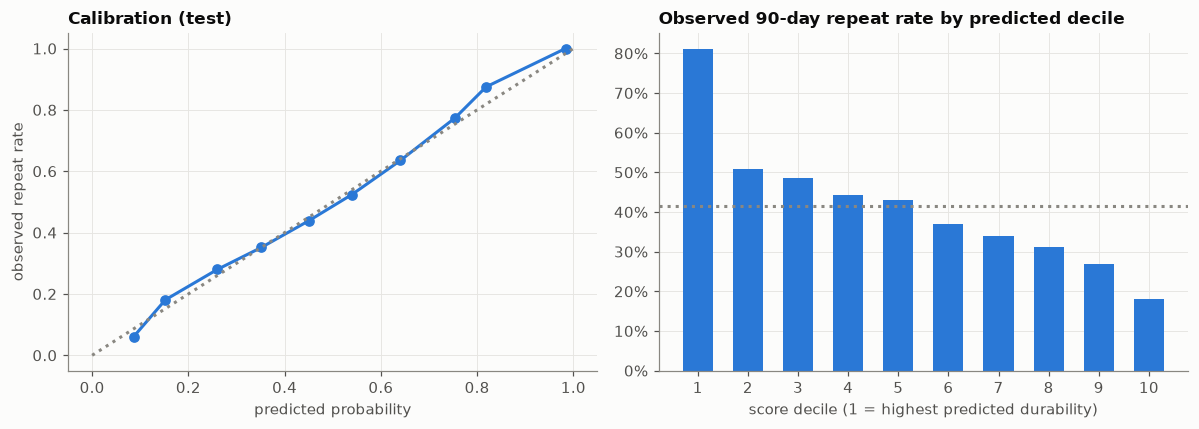

,customers,repeat_rate,cm_90d
decile,,,
1,638,0.810,131.287
2,638,0.508,91.732
3,638,0.486,74.363
4,638,0.442,67.809
5,637,0.430,58.641
6,638,0.370,50.079
7,638,0.340,45.732
8,638,0.312,33.556
9,638,0.268,24.915


In [8]:
p = proba[best]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
frac, mean_pred = calibration_curve(yte, p, n_bins=10)
ax[0].plot(mean_pred, frac, marker="o", color=viz.SERIES[0]); ax[0].plot([0, 1], [0, 1], color=viz.MUTED, linestyle=":")
ax[0].set_xlabel("predicted probability"); ax[0].set_ylabel("observed repeat rate"); ax[0].set_title("Calibration (test)")
te_df = df[te].assign(score=p)
te_df["decile"] = pd.qcut(te_df.score.rank(method="first"), 10, labels=range(10, 0, -1)).astype(int)
dec = te_df.groupby("decile").agg(customers=("customer_id", "size"), repeat_rate=("repeat_90d", "mean"), cm_90d=("cm_90d", "mean")).sort_index()
ax[1].bar(dec.index.astype(str), dec.repeat_rate, color=viz.SERIES[0], width=0.6); ax[1].axhline(yte.mean(), color=viz.MUTED, linestyle=":")
ax[1].yaxis.set_major_formatter(FuncFormatter(viz.pct)); ax[1].set_xlabel("score decile (1 = highest predicted durability)"); ax[1].set_title("Observed 90-day repeat rate by predicted decile")
plt.tight_layout(); plt.savefig("../images/07_calibration_deciles.png"); plt.show()
dec.round(3)

In [9]:
top = te_df[te_df.decile <= 2]
print(f"top 20% by score: {len(top):,} customers, repeat rate {top.repeat_90d.mean():.1%} vs {yte.mean():.1%} baseline (lift {top.repeat_90d.mean()/yte.mean():.2f}×)")
print(f"they contain {top.repeat_90d.sum()/te_df.repeat_90d.sum():.0%} of all eventual repeaters and {top.cm_90d.sum()/te_df.cm_90d.sum():.0%} of all 90-day contribution margin")
bottom = te_df[te_df.decile >= 9]
print(f"bottom 20%: repeat rate {bottom.repeat_90d.mean():.1%}, mean 90-day CM ${bottom.cm_90d.mean():.0f} vs ${te_df.cm_90d.mean():.0f} overall")

top 20% by score: 1,276 customers, repeat rate 65.9% vs 41.5% baseline (lift 1.59×)
they contain 32% of all eventual repeaters and 38% of all 90-day contribution margin
bottom 20%: repeat rate 22.4%, mean 90-day CM $21 vs $59 overall


## 6. Signals summarised

In [10]:
sig = df.groupby("used_discount").repeat_90d.mean().rename({0: "no discount", 1: "discount used"}).to_frame("repeat_90d")
sig2 = df.groupby(pd.cut(df.sessions_7d, [-1, 0, 1, 2, 10], labels=["0", "1", "2", "3+"])).repeat_90d.mean().to_frame("repeat_90d")
sig3 = df.groupby("first_order_refunded_7d").repeat_90d.mean().rename({0: "no refund by day 7", 1: "refund by day 7"}).to_frame("repeat_90d")
print("by first-order discount:\n", sig.round(3), "\n\nby sessions in first 7 days (excl. acquisition):\n", sig2.round(3), "\n\nby early refund:\n", sig3.round(3))

by first-order discount:
                repeat_90d
used_discount            
no discount         0.468
discount used       0.340 

by sessions in first 7 days (excl. acquisition):
              repeat_90d
sessions_7d            
0                 0.357
1                 0.502
2                 0.590
3+                0.666 

by early refund:
                          repeat_90d
first_order_refunded_7d            
no refund by day 7            0.409
refund by day 7               0.245


In [11]:
perf.to_csv("../data/processed/model_performance.csv"); imp_grouped.to_csv("../data/processed/model_permutation_importance.csv")

**Takeaways.**
- Durable customers can be identified early with **modest but useful** accuracy (ROC-AUC ≈ 0.68): the
  top-scored decile repeats at about twice the base rate and the top 20% at 1.6×, capturing roughly a third of
  eventual repeaters and nearly 40% of 90-day margin.
- The strongest early signals are **behavioural and transactional** — return visits in the first week,
  first-order value, discount used, first-order category, an early refund — plus **creator tier** and the
  campaign's **save rate**.
- Campaign virality features add almost nothing once those are known. That is consistent with the statistical
  analysis: what predicts value is what the customer did and what offer brought them, not how far the post travelled.